# Module 2 Hazard and Exposure Indicators

Module 1 produced trends in raw climate variables. 
This module converts climate into hazard indicators that map onto actual
decisions: drought (SPEI), fire weather (ERC and VPD threshold exceedance),
water supply (SNOTEL snowpack timing), and low flow (USGS gauges).

Each is standardized so it can be compared across regions in Module 3, which
requires being explicit about what standardization destroys as well as what it
enables.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from daear_toolkit import climate_access as ca
from daear_toolkit import climate_indicators as ci

REGIONS = [ca.POUDRE, ca.BLACK_HILLS, ca.FRONT_RANGE]
BASELINE = slice("1991", "2020")
colors = {"poudre": "#b5443a", "black_hills": "#2f6f4e", "front_range": "#3b6ea5"}

## Drought (SPEI, not SPI)

SPI uses precipitation alone. SPEI uses the climatic water balance, P-PET.

That difference is not academic in the interior West: rising evaporative demand
has driven substantial drying that precipitation-only indices miss entirely.
Both are computed below precisely so the gap is visible and that gap is the
warming signal in drought, which is the whole argument for using SPEI.

A 12-month accumulation is used here because it tracks reservoir storage and
groundwater, which is the decision this supports. Use 3-month for
soil-moisture and agricultural drought instead. Always name the scale as an
unlabelled "SPEI" is not interpretable.

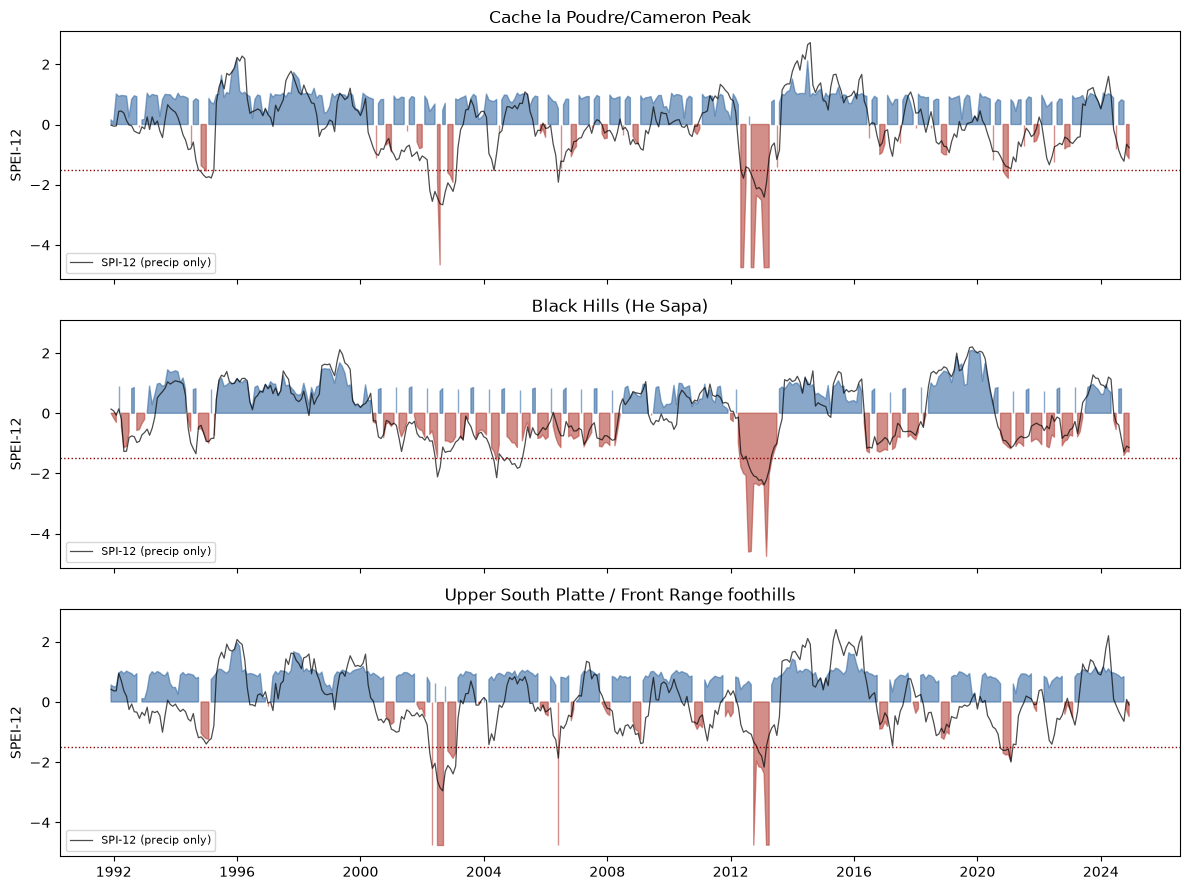

poudre         mean SPEI-12 2015-2024: +0.48   mean SPI-12: -0.04   gap (the evaporative-demand signal): +0.52
black_hills    mean SPEI-12 2015-2024: +0.17   mean SPI-12: +0.18   gap (the evaporative-demand signal): -0.00
front_range    mean SPEI-12 2015-2024: +0.54   mean SPI-12: +0.06   gap (the evaporative-demand signal): +0.48


In [2]:
monthly = {}
for r in REGIONS:
    ds = ca.get_gridmet(r, variables=("pr", "pet"), start="1991-01-01", end="2024-12-31")
    spatial = ds.mean(dim=[d for d in ds.dims if d != "day"]).to_dataframe()
    monthly[r.key] = pd.DataFrame({
        "precip": spatial["pr"].resample("MS").sum(),
        "pet":    spatial["pet"].resample("MS").sum(),
    })

drought = {}
for r in REGIONS:
    m = monthly[r.key]
    drought[r.key] = pd.DataFrame({
        "spi12":  ci.spi(m["precip"], scale=12, calibration=BASELINE),
        "spei12": ci.spei(m["precip"], m["pet"], scale=12, calibration=BASELINE),
    })

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, sharey=True)
for ax, r in zip(axes, REGIONS):
    d = drought[r.key]
    ax.fill_between(d.index, 0, d["spei12"], where=d["spei12"] < 0, color="#b5443a", alpha=0.6)
    ax.fill_between(d.index, 0, d["spei12"], where=d["spei12"] >= 0, color="#3b6ea5", alpha=0.6)
    ax.plot(d.index, d["spi12"], color="black", lw=0.9, alpha=0.7, label="SPI-12 (precip only)")
    ax.axhline(-1.5, color="darkred", ls=":", lw=1)
    ax.set_ylabel("SPEI-12"); ax.set_title(r.name); ax.legend(fontsize=8, loc="lower left")

plt.tight_layout()
plt.savefig("../outputs/02_drought_indices.png", dpi=150)
plt.show()

for r in REGIONS:
    d = drought[r.key].dropna()
    recent = d.loc["2015":]
    print(f"{r.key:<14} mean SPEI-12 2015-2024: {recent['spei12'].mean():+.2f}   "
          f"mean SPI-12: {recent['spi12'].mean():+.2f}   "
          f"gap (the evaporative-demand signal): {recent['spei12'].mean() - recent['spi12'].mean():+.2f}")

## Fire weather

Two definitions, kept separate because they answer different questions.

**ERC above its 1991–2020 90th percentile.** Energy Release Component integrates
fuel moisture across size classes and is what fire managers actually use, so this
version is legible to an operational audience.

**VPD above 2 kPa.** Cleaner physically, and better for attribution as it does not
depend on a fuel model whose parameters themselves changed after the fire.

The baseline is fixed at 1991–2020 for both. Computing the percentile on the
full moving record would let the threshold drift upward with the climate,
mechanically erasing the trend.

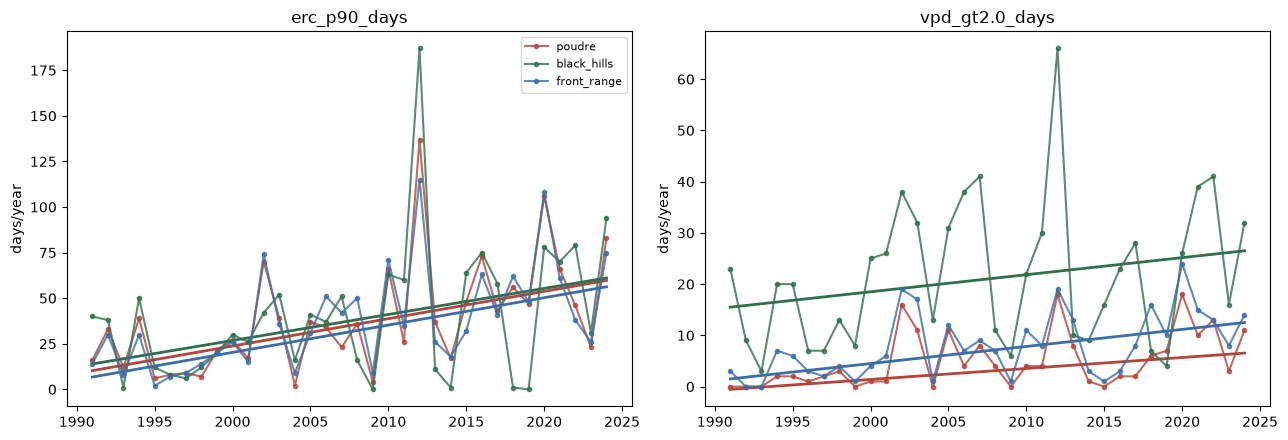

,region,metric,days_per_decade,p_corrected,significant
0,poudre,erc_p90_days,15.00,0.0005,True
1,poudre,vpd_gt2.0_days,2.14,0.0024,True
2,black_hills,erc_p90_days,14.29,0.0176,True
3,black_hills,vpd_gt2.0_days,3.33,0.1357,False
4,front_range,erc_p90_days,15.00,0.0003,True
5,front_range,vpd_gt2.0_days,3.33,0.0017,True


In [3]:
fire = {}
for r in REGIONS:
    ds = ca.get_gridmet(r, variables=("erc", "vpd"), start="1991-01-01", end="2024-12-31")
    spatial = ds.mean(dim=[d for d in ds.dims if d != "day"]).to_dataframe()
    fire[r.key] = ci.fire_weather_days(
        erc=spatial["erc"], vpd=spatial["vpd"],
        erc_percentile=90, vpd_threshold=2.0, baseline=BASELINE,
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for r in REGIONS:
    f = fire[r.key]
    for ax, col in zip(axes, f.columns):
        ax.plot(f.index, f[col], "o-", ms=3, color=colors[r.key], alpha=0.8, label=r.key)
        t = ci.theil_sen_trend(f[col].values, f.index.values, per_decade=False)
        ax.plot(f.index, t["intercept"] + t["slope"] * f.index.values, color=colors[r.key], lw=2)
        ax.set_title(col); ax.set_ylabel("days/year")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("../outputs/02_fire_weather_days.png", dpi=150)
plt.show()

rows = []
for r in REGIONS:
    for col in fire[r.key].columns:
        t = ci.theil_sen_trend(fire[r.key][col].values, fire[r.key].index.values)
        mk = ci.mann_kendall(fire[r.key][col].values, autocorr_correction=True)
        rows.append({"region": r.key, "metric": col, "days_per_decade": round(t["slope"], 2),
                     "p_corrected": round(mk["p_value"], 4), "significant": mk["p_value"] < 0.05})
pd.DataFrame(rows)

## Snowpack (peak SWE and melt-out timing)

SNOTEL, via the NRCS AWDB REST service.

Melt-out date carries more water-supply information than peak SWE. Two years
with identical peaks but three weeks' difference in melt-out produce very
different summer streamflow and very different fire seasons: peak SWE is a
stock, melt-out is what governs the flow.

**SNOTEL sites were deliberately sited to be *representative of snow*, 
which means they cluster in mid-to-upper elevation forest openings and 
systematically under-sample both low elevation and alpine terrain. A SNOTEL 
trend is a trend at SNOTEL elevations. It is not a basin-wide trend, and 
presenting it as one is the most common overreach in this kind of analysis.

poudre: 36 SNOTEL stations, elevations 4870-10710 ft
black_hills: 26 SNOTEL stations, elevations 3010-6900 ft
front_range: 29 SNOTEL stations, elevations 4960-10660 ft


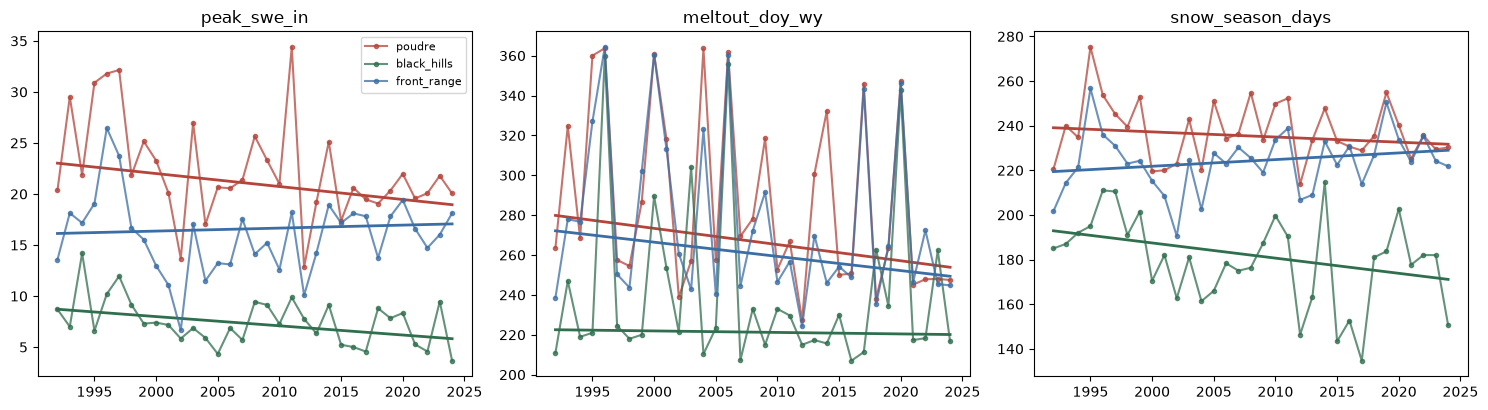

poudre         peak_swe_in        -1.27/decade   p=0.025  *
poudre         meltout_doy_wy     -8.12/decade   p=0.030  *
black_hills    peak_swe_in        -0.90/decade   p=0.041  *
black_hills    meltout_doy_wy     -0.75/decade   p=0.733
front_range    peak_swe_in        +0.29/decade   p=0.698
front_range    meltout_doy_wy     -7.12/decade   p=0.215


In [4]:
snow = {}
for r in REGIONS:
    stations = ca.get_snotel_stations(state=r.snotel_state, bbox=r.bbox)
    if stations.empty:
        print(f"{r.key}: no SNOTEL stations in bbox")
        continue
    print(f"{r.key}: {len(stations)} SNOTEL stations, elevations "
          f"{stations['elev_ft'].min():.0f}-{stations['elev_ft'].max():.0f} ft")
    swe = ca.get_snotel_data(stations["triplet"].tolist(), element="WTEQ",
                             start="1991-10-01", end="2024-09-30")
    snow[r.key] = ci.snow_metrics(swe)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for r in REGIONS:
    if r.key not in snow or snow[r.key].empty:
        continue
    agg = snow[r.key].groupby("water_year")[["peak_swe_in", "meltout_doy_wy", "snow_season_days"]].mean()
    for ax, col in zip(axes, ["peak_swe_in", "meltout_doy_wy", "snow_season_days"]):
        ax.plot(agg.index, agg[col], "o-", ms=3, color=colors[r.key], alpha=0.75, label=r.key)
        t = ci.theil_sen_trend(agg[col].values, agg.index.values, per_decade=False)
        ax.plot(agg.index, t["intercept"] + t["slope"] * agg.index.values, color=colors[r.key], lw=2)
        ax.set_title(col)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("../outputs/02_snow_metrics.png", dpi=150)
plt.show()

for r in REGIONS:
    if r.key not in snow or snow[r.key].empty:
        continue
    agg = snow[r.key].groupby("water_year")[["peak_swe_in", "meltout_doy_wy"]].mean()
    for col in agg.columns:
        t = ci.theil_sen_trend(agg[col].values, agg.index.values)
        mk = ci.mann_kendall(agg[col].values, autocorr_correction=True)
        print(f"{r.key:<14} {col:<16} {t['slope']:+7.2f}/decade   p={mk['p_value']:.3f}"
              f"{'  *' if mk['p_value'] < 0.05 else ''}")

## Low flow

USGS NWIS daily discharge, reduced to annual 7-day minimum and days below the
long-term 10th percentile.

Low flow rather than mean flow, because mean annual flow is dominated by peak
snowmelt and can stay flat while the summer minimum collapses and the summer
minimum is where the ecological and water-supply challenges are.

**Two filters before any trend is computed.** Record length, because a 12-year
gauge will happily produce a significant-looking slope that is decadal
variability. And regulation, which is the harder problem: many Front Range
gauges sit below transbasin diversions and reservoirs, so their trends measure
operations rather than climate. That screening is a manual read of NWIS site
descriptions and it cannot be automated away.

In [5]:
flow = {}
for r in REGIONS:
    raw = ca.get_streamflow(bbox=r.bbox, start="1991-01-01", end="2024-12-31")
    if raw.empty:
        print(f"{r.key}: no gauges returned")
        continue
    filtered = ca.filter_by_record_length(raw, min_years=25, max_gap_frac=0.1)
    print(f"{r.key}: {raw['site_no'].nunique()} gauges {filtered['site_no'].nunique()} after record-length filter")
    for site, name in filtered.groupby('site_no')['site_name'].first().items():
        print(f"    {site}  {name}")
    flow[r.key] = ci.low_flow_metrics(filtered)

print("\nREVIEW THESE SITE NAMES BEFORE INTERPRETING ANY TREND.")
print("Names containing 'BLW', 'RES', 'DIVERSION', 'CANAL', or 'DITCH' indicate")
print("regulated flow: those trends reflect operations, not climate, and should")
print("be dropped or reported separately.")

poudre: 10 gauges 7 after record-length filter
    06614800  MICHIGAN RIVER NEAR CAMERON PASS, CO
    06746095  JOE WRIGHT CREEK ABOVE JOE WRIGHT RESERVOIR, CO
    06746110  JOE WRIGHT CREEK BELOW JOE WRIGHT RESERVOIR, CO
    06751150  N FK CACHE LA POUDRE R BLW HALLIGAN RES NR VA DALE
    06751490  NORTH FORK CACHE LA POUDRE RIVER AT LIVERMORE, CO
    06752260  CACHE LA POUDRE RIVER AT FORT COLLINS, CO
    06752280  CACHE LA POUDRE RIV AB BOXELDER CRK NR TIMNATH, CO
black_hills: 63 gauges 30 after record-length filter
    06392900  BEAVER CREEK AT MALLO CAMP, NEAR FOUR CORNERS, WY
    06392950  STOCKADE BEAVER CREEK NEAR NEWCASTLE, WY
    06402000  FALL RIVER AT HOT SPRINGS, SD
    06402430  BEAVER CREEK NEAR PRINGLE, SD
    06402500  BEAVER CREEK NEAR BUFFALO GAP, SD
    06403300  FRENCH CREEK ABOVE FAIRBURN, SD
    06404000  BATTLE CREEK NEAR KEYSTONE, SD
    06404998  GRACE COOLIDGE CREEK NR GAME LODGE NR CUSTER, SD
    06407500  SPRING CREEK NEAR KEYSTONE, SD
    06408700  RHOADS 

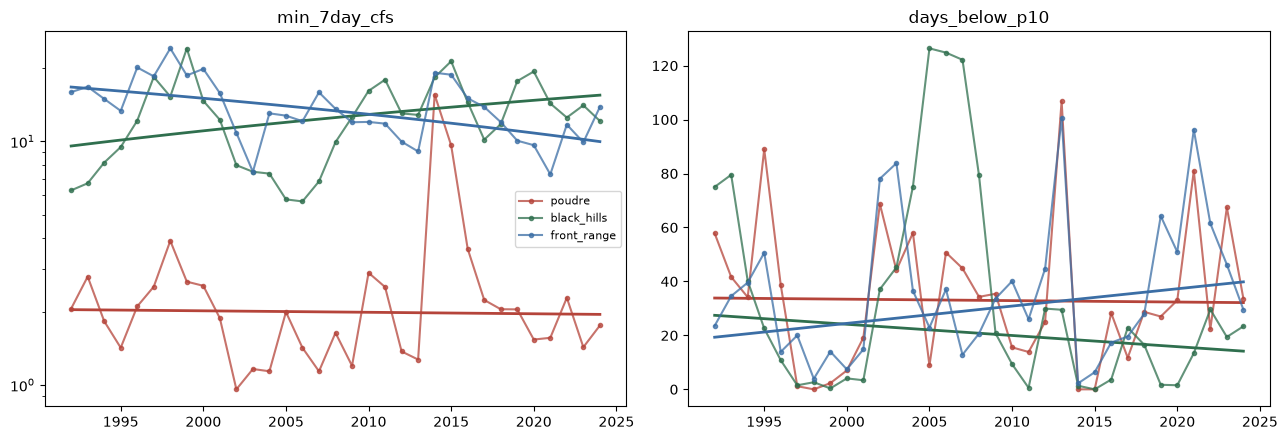

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for r in REGIONS:
    if r.key not in flow or flow[r.key].empty:
        continue
    agg = flow[r.key].groupby("water_year")[["min_7day_cfs", "days_below_p10"]].mean()
    for ax, col in zip(axes, agg.columns):
        ax.plot(agg.index, agg[col], "o-", ms=3, color=colors[r.key], alpha=0.75, label=r.key)
        t = ci.theil_sen_trend(agg[col].values, agg.index.values, per_decade=False)
        ax.plot(agg.index, t["intercept"] + t["slope"] * agg.index.values, color=colors[r.key], lw=2)
        ax.set_title(col)
axes[0].set_yscale("log")   # discharge spans orders of magnitude across gauges
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("../outputs/02_low_flow.png", dpi=150)
plt.show()

## Assemble the indicator table

One row per region, one column per hazard indicator; these are the direct input to
Module 3's composite index.

Everything is expressed as a *trend*, not a level, so that regions with
different absolute climates remain comparable. A region can be dry without
getting drier, and for resilience planning the direction of travel is the
relevant quantity.

In [7]:
def trend_of(series, index):
    t = ci.theil_sen_trend(np.asarray(series), np.asarray(index), per_decade=True)
    mk = ci.mann_kendall(np.asarray(series), autocorr_correction=True)
    return t["slope"], mk["p_value"]

rows = []
for r in REGIONS:
    row = {"region": r.key, "name": r.name}

    d = drought[r.key].dropna()
    row["spei_trend"], row["spei_p"] = trend_of(d["spei12"].resample("YS").mean().values,
                                                d["spei12"].resample("YS").mean().index.year)
    f = fire[r.key]
    row["vpd_days_trend"], row["vpd_days_p"] = trend_of(f.iloc[:, 1].values, f.index.values)
    row["erc_days_trend"], row["erc_days_p"] = trend_of(f.iloc[:, 0].values, f.index.values)

    if r.key in snow and not snow[r.key].empty:
        agg = snow[r.key].groupby("water_year")[["peak_swe_in", "meltout_doy_wy"]].mean()
        row["peak_swe_trend"], row["peak_swe_p"] = trend_of(agg["peak_swe_in"].values, agg.index.values)
        row["meltout_trend"], row["meltout_p"] = trend_of(agg["meltout_doy_wy"].values, agg.index.values)

    if r.key in flow and not flow[r.key].empty:
        agg = flow[r.key].groupby("water_year")["min_7day_cfs"].mean()
        row["low_flow_trend"], row["low_flow_p"] = trend_of(agg.values, agg.index.values)

    rows.append(row)

indicators = pd.DataFrame(rows).set_index("region").round(4)
indicators.to_csv("../outputs/02_hazard_indicators.csv")
indicators

,name,spei_trend,spei_p,vpd_days_trend,vpd_days_p,erc_days_trend,erc_days_p,peak_swe_trend,peak_swe_p,meltout_trend,meltout_p,low_flow_trend,low_flow_p
region,,,,,,,,,,,,,
poudre,Cache la Poudre/Cameron Peak,-0.1029,0.2130,2.1429,0.0024,15.0000,0.0005,-1.2709,0.0247,-8.1250,0.0300,-0.0278,0.8423
black_hills,Black Hills (He Sapa),-0.1114,0.3937,3.3333,0.1357,14.2857,0.0176,-0.9028,0.0408,-0.7512,0.7331,1.8451,0.0608
front_range,Upper South Platte / Front Range foothills,-0.0931,0.2074,3.3333,0.0017,15.0000,0.0003,0.2925,0.6985,-7.1237,0.2151,-2.1029,0.0035


## Summary

Five hazard indicators across three regions, each a trend per decade with an
autocorrelation-corrected p-value: drought (SPEI-12), fire weather (VPD and ERC
exceedance days), snowpack (peak SWE and melt-out timing), and low flow.

`indicators` feeds Module 3 directly.

**What each indicator can and cannot support:**

| Indicator | Supports | Does not support |
|---|---|---|
| SPEI-12 | reservoir and groundwater drought | soil-moisture drought (use SPEI-3) |
| VPD days | fire-weather trend attribution | operational fire danger (use ERC) |
| Peak SWE / melt-out | water-supply timing at SNOTEL elevations | basin-wide snowpack |
| Low flow | ecological and supply stress at unregulated gauges | anything below a diversion |

The regulation screening is the weakest link and the one a hydrologist
will ask about first. It is a manual read of site descriptions, and it should be
done with a local water engineer rather than by pattern-matching on site names.